# Hyperparameter Optimization for Machine Learning Models

**Author:** Phabel Antonio López Delgado, BSc.

This notebook demonstrates a variety of hyperparameter optimization techniques applied to a classification problem using the Wine Quality dataset. It covers:

- **Grid Search** – exhaustive search over a predefined hyperparameter grid.
- **Random Search** – randomised search over a wider hyperparameter space.
- **Bayesian Optimization** – using `scikit-optimize` and `Optuna`.
- **Genetic Algorithm** – using `DEAP` to evolve hyperparameter sets.
- **Particle Swarm Optimization** – using `pyswarms` to find optimal parameters.

**Key Techniques & Libraries:**
- `numpy`, `pandas` – data manipulation
- `matplotlib`, `seaborn` – visualisation
- `scikit-learn` – models, preprocessing, cross‑validation, grid/random search
- `scikit-optimize` – Bayesian optimisation with `BayesSearchCV`
- `optuna` – Bayesian optimisation with TPE sampler
- `deap` – genetic algorithm framework
- `pyswarms` – particle swarm optimisation

**Dataset:**
Wine Quality Dataset – contains physicochemical properties and a sensory quality score. The goal is to predict wine quality (low, medium, high) from chemical attributes. The dataset is assumed to be located at `../data/winequality.csv`.

In [5]:
# %% Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

# Grid and Random Search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Bayesian Optimization with scikit-optimize
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real

# Bayesian Optimization with Optuna
import optuna
from optuna.samplers import TPESampler

# Genetic Algorithm (DEAP)
from deap import base, creator, tools, algorithms
import random

# Particle Swarm Optimization (pyswarms)
import pyswarms as ps

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print("All imports successful.")

All imports successful.


## 1. Data Loading and Preprocessing

We load the Wine Quality dataset, map the wine type to numeric, and transform the target variable into three quality categories (low, medium, high). We then split the data and scale the features appropriately.

In [6]:
# %% Data Loading and Preprocessing
# Load dataset (adjust path if needed)
data = pd.read_csv('../data/winequality.csv')
print("Dataset shape:", data.shape)
data.head()

# Map wine type to numeric: white -> 0, red -> 1
type_mapping = {'white': 0, 'red': 1}
data['type'] = data['type'].map(type_mapping)
data = data.dropna()

# Transform target: 0 (low: 3-5), 1 (medium: 6), 2 (high: 7-10)
data["quality"] = data["quality"].replace({3:0, 4:0, 5:0, 6:1, 7:2, 8:2, 9:2, 10:2})
y = data["quality"]
X = data.drop('quality', axis=1)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.20, random_state=21
)

# Feature scaling: StandardScaler for most, MinMaxScaler for pH
standard_cols = [col for col in X.columns if col != 'pH']
minmax_cols = ['pH']

ct = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), standard_cols),
        ('minmax', MinMaxScaler(feature_range=(0, 14)), minmax_cols)
    ],
    remainder='passthrough'
)

ct.fit(X_train)
X_train_scaled = ct.transform(X_train)
X_test_scaled = ct.transform(X_test)

print("Training set size:", X_train_scaled.shape[0])
print("Test set size:", X_test_scaled.shape[0])

Dataset shape: (6497, 13)
Training set size: 5170
Test set size: 1293


## 2. Baseline Model (No Tuning)

A K‑Nearest Neighbors classifier with default parameters serves as the baseline for comparison.

In [7]:
# %% Baseline Model
def evaluate_model(model, X_test, y_test):
    return f1_score(y_test, model.predict(X_test), average='weighted')

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
baseline_score = evaluate_model(knn, X_test_scaled, y_test)
print(f"Baseline F1 (weighted): {baseline_score:.4f}")

Baseline F1 (weighted): 0.5947


## 3. Grid Search

Exhaustive search over a predefined hyperparameter grid using stratified cross‑validation (5 folds).

In [8]:
# %% Grid Search
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'weights': ['uniform', 'distance'],
    'leaf_size': [10, 20, 30, 40],
    'p': [1, 2]
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    scoring='f1_weighted',
    cv=stratified_cv,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score: {:.4f}".format(grid_search.best_score_))
grid_best = grid_search.best_estimator_
print("Test F1: {:.4f}".format(evaluate_model(grid_best, X_test_scaled, y_test)))

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best parameters: {'leaf_size': 10, 'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
Best CV score: 0.6872
Test F1: 0.6749


## 4. Random Search

Randomised search over a wider hyperparameter space, sampling a fixed number of combinations (70).

In [9]:
# %% Random Search
knn_param_grid_big = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 20, 25, 35],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree'],
    'leaf_size': [10, 20, 30, 40],
    'p': [1, 2]
}

random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    knn_param_grid_big,
    scoring='f1_weighted',
    n_iter=70,
    cv=stratified_cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train_scaled, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV score: {:.4f}".format(random_search.best_score_))
rand_best = random_search.best_estimator_
print("Test F1: {:.4f}".format(evaluate_model(rand_best, X_test_scaled, y_test)))

Fitting 5 folds for each of 70 candidates, totalling 350 fits
Best parameters: {'weights': 'distance', 'p': 1, 'n_neighbors': 35, 'leaf_size': 30, 'algorithm': 'ball_tree'}
Best CV score: 0.6936
Test F1: 0.6994


## 5. Bayesian Optimization with scikit-optimize

Uses a probabilistic model (Gaussian process) to guide the search, balancing exploration and exploitation.

In [10]:
# %% Bayesian Optimization with scikit-optimize
knn_bayes_space = {
    'n_neighbors': Integer(2, 50),
    'weights': Categorical(['uniform', 'distance']),
    'algorithm': Categorical(['auto', 'ball_tree', 'kd_tree']),
    'leaf_size': Integer(10, 40),
    'p': Integer(1, 2),
}

bayes_search = BayesSearchCV(
    estimator=KNeighborsClassifier(),
    search_spaces=knn_bayes_space,
    n_iter=40,
    cv=stratified_cv,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=4
)
bayes_search.fit(X_train_scaled, y_train)

print("Best parameters:", bayes_search.best_params_)
print("Best CV score: {:.4f}".format(bayes_search.best_score_))
bayes_best = bayes_search.best_estimator_
print("Test F1: {:.4f}".format(evaluate_model(bayes_best, X_test_scaled, y_test)))

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

## 6. Bayesian Optimization with Optuna

Optuna provides a more flexible framework where the objective function is defined explicitly, allowing custom cross‑validation and metrics. We use the TPE sampler.

In [11]:
# %% Bayesian Optimization with Optuna
def objective(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 50),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree']),
        'leaf_size': trial.suggest_int('leaf_size', 10, 40),
        'p': trial.suggest_int('p', 1, 2),
    }
    model = KNeighborsClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=5
    )
    return np.mean(scores)

study = optuna.create_study(direction='maximize', sampler=TPESampler(n_startup_trials=50, seed=42))
study.optimize(objective, n_trials=100, timeout=600)

print("Best F1 (weighted): {:.4f}".format(study.best_value))
print("Best hyperparameters:", study.best_params)

best_params_optuna = study.best_params
best_model_optuna = KNeighborsClassifier(**best_params_optuna)
best_model_optuna.fit(X_train_scaled, y_train)
print("Test F1: {:.4f}".format(evaluate_model(best_model_optuna, X_test_scaled, y_test)))

[I 2026-07-21 09:37:48,809] A new study created in memory with name: no-name-65f8a770-0dc4-40c3-9919-c89877a53146
[I 2026-07-21 09:37:51,470] Trial 0 finished with value: 0.5937520227825346 and parameters: {'n_neighbors': 20, 'weights': 'uniform', 'algorithm': 'auto', 'leaf_size': 11, 'p': 2}. Best is trial 0 with value: 0.5937520227825346.
[I 2026-07-21 09:37:51,642] Trial 1 finished with value: 0.5930154798389057 and parameters: {'n_neighbors': 31, 'weights': 'uniform', 'algorithm': 'auto', 'leaf_size': 15, 'p': 1}. Best is trial 0 with value: 0.5937520227825346.
[I 2026-07-21 09:37:51,766] Trial 2 finished with value: 0.608296337355408 and parameters: {'n_neighbors': 17, 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 19, 'p': 1}. Best is trial 2 with value: 0.608296337355408.
[I 2026-07-21 09:37:51,906] Trial 3 finished with value: 0.5984006185507041 and parameters: {'n_neighbors': 24, 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 28, 'p': 1}. Best is tr

[I 2026-07-21 09:37:56,255] Trial 35 finished with value: 0.6884898021281478 and parameters: {'n_neighbors': 45, 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 24, 'p': 2}. Best is trial 20 with value: 0.6944110024221305.
[I 2026-07-21 09:37:56,427] Trial 36 finished with value: 0.5922440577669741 and parameters: {'n_neighbors': 16, 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 13, 'p': 2}. Best is trial 20 with value: 0.6944110024221305.
[I 2026-07-21 09:37:56,538] Trial 37 finished with value: 0.6904406116820173 and parameters: {'n_neighbors': 39, 'weights': 'distance', 'algorithm': 'kd_tree', 'leaf_size': 26, 'p': 2}. Best is trial 20 with value: 0.6944110024221305.
[I 2026-07-21 09:37:56,709] Trial 38 finished with value: 0.5928124049571883 and parameters: {'n_neighbors': 37, 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 23, 'p': 1}. Best is trial 20 with value: 0.6944110024221305.
[I 2026-07-21 09:37:56,864] Trial 39 finished with value

[I 2026-07-21 09:38:01,482] Trial 71 finished with value: 0.6937368401111744 and parameters: {'n_neighbors': 24, 'weights': 'distance', 'algorithm': 'auto', 'leaf_size': 22, 'p': 1}. Best is trial 41 with value: 0.6972084297294345.
[I 2026-07-21 09:38:01,622] Trial 72 finished with value: 0.6972084297294345 and parameters: {'n_neighbors': 23, 'weights': 'distance', 'algorithm': 'auto', 'leaf_size': 18, 'p': 1}. Best is trial 41 with value: 0.6972084297294345.
[I 2026-07-21 09:38:01,762] Trial 73 finished with value: 0.6944110024221305 and parameters: {'n_neighbors': 20, 'weights': 'distance', 'algorithm': 'auto', 'leaf_size': 19, 'p': 1}. Best is trial 41 with value: 0.6972084297294345.
[I 2026-07-21 09:38:01,904] Trial 74 finished with value: 0.6950567304861169 and parameters: {'n_neighbors': 18, 'weights': 'distance', 'algorithm': 'auto', 'leaf_size': 16, 'p': 1}. Best is trial 41 with value: 0.6972084297294345.
[I 2026-07-21 09:38:02,030] Trial 75 finished with value: 0.693301484156

Best F1 (weighted): 0.6972
Best hyperparameters: {'n_neighbors': 23, 'weights': 'distance', 'algorithm': 'auto', 'leaf_size': 11, 'p': 1}
Test F1: 0.6965


## 7. Genetic Algorithm (DEAP)

This section uses the DEAP library to implement a genetic algorithm that evolves a population of hyperparameter sets over generations. The fitness is the cross‑validated F1 score.


In [12]:
# %% Genetic Algorithm (DEAP)
# Options for categorical parameters
knn_weights = ['uniform', 'distance']
knn_algorithms = ['auto', 'ball_tree', 'kd_tree', 'brute']

# Define fitness and individual types
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Register parameter generators
toolbox.register("n_neighbors", random.randint, 1, 1000)
toolbox.register("leaf_size", random.randint, 1, 1000)
toolbox.register("weights_idx", random.randint, 0, len(knn_weights)-1)
toolbox.register("algorithm_idx", random.randint, 0, len(knn_algorithms)-1)
toolbox.register("p_value", random.randint, 1, 5)  # p for Minkowski distance

# Create individual and population
toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    (
        toolbox.n_neighbors,
        toolbox.weights_idx,
        toolbox.algorithm_idx,
        toolbox.leaf_size,
        toolbox.p_value
    ),
    n=1
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Evaluation function
def evaluate(individual):
    params = {
        'n_neighbors': max(1, individual[0]),
        'weights': knn_weights[individual[1] % len(knn_weights)],
        'algorithm': knn_algorithms[individual[2] % len(knn_algorithms)],
        'leaf_size': max(1, individual[3]),
        'p': max(1, min(5, abs(individual[4])))
    }
    model = KNeighborsClassifier(**params)
    scores = cross_val_score(
        model,
        X_train_scaled, y_train,
        cv=stratified_cv,
        scoring='f1_weighted',
        n_jobs=-1
    )
    return (np.mean(scores),)

toolbox.register("evaluate", evaluate)

# Custom mutation
def mutUnbounded(individual, indpb):
    for i in range(len(individual)):
        if random.random() < indpb:
            if i == 0:  # n_neighbors
                step = max(1, int(individual[i] * 0.2))
                individual[i] = max(1, individual[i] + random.randint(-step, step))
            elif i == 3:  # leaf_size
                individual[i] = max(1, individual[i] + random.randint(-10, 10))
            elif i in [1, 2]:  # categorical indices
                if i == 1:
                    individual[i] = random.randint(0, len(knn_weights)-1)
                else:
                    individual[i] = random.randint(0, len(knn_algorithms)-1)
            else:  # p
                individual[i] += random.gauss(0, 0.5)
    return individual,

toolbox.register("mutate", mutUnbounded, indpb=0.3)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("select", tools.selTournament, tournsize=3)

# Run genetic algorithm
population = toolbox.population(n=20)
hof = tools.HallOfFame(5)

stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("min", np.min)
stats.register("max", np.max)

result, log = algorithms.eaSimple(
    population, toolbox,
    cxpb=0.7,
    mutpb=0.3,
    ngen=50,
    halloffame=hof,
    stats=stats,
    verbose=True
)

# Best solution
best_ind = hof[0]
best_params_deap = {
    'n_neighbors': max(1, best_ind[0]),
    'weights': knn_weights[best_ind[1] % len(knn_weights)],
    'algorithm': knn_algorithms[best_ind[2] % len(knn_algorithms)],
    'leaf_size': max(1, best_ind[3]),
    'p': max(1, min(5, abs(best_ind[4]))),
}

print("\nBest hyperparameters (DEAP):")
for k, v in best_params_deap.items():
    print(f"{k:>15}: {v}")

final_model_deap = KNeighborsClassifier(**best_params_deap)
final_model_deap.fit(X_train_scaled, y_train)
print("Test F1: {:.4f}".format(evaluate_model(final_model_deap, X_test_scaled, y_test)))

gen	nevals	avg    	min     	max     
0  	20    	0.56927	0.418697	0.680606
1  	13    	0.623843	0.448414	0.686292
2  	15    	0.676376	0.627546	0.691917
3  	15    	0.685809	0.680606	0.691043
4  	14    	0.690326	0.683053	0.69468 
5  	15    	0.681429	0.572989	0.69468 
6  	17    	0.688307	0.589647	0.69468 
7  	17    	0.694002	0.690395	0.695805
8  	16    	0.688898	0.582739	0.695805
9  	17    	0.683816	0.583375	0.695805
10 	16    	0.69451 	0.69025 	0.695805
11 	18    	0.684387	0.583532	0.695805
12 	19    	0.69497 	0.687112	0.695805
13 	19    	0.690258	0.586984	0.695805
14 	20    	0.679066	0.585522	0.695805
15 	15    	0.684739	0.585797	0.695805
16 	17    	0.684676	0.585522	0.695805
17 	17    	0.690176	0.586984	0.695805
18 	15    	0.69537 	0.69011 	0.695805
19 	16    	0.690116	0.586984	0.695805
20 	15    	0.695387	0.692425	0.695805
21 	16    	0.690093	0.586984	0.695805
22 	15    	0.689487	0.586984	0.695805
23 	13    	0.690281	0.587943	0.695805
24 	15    	0.695205	0.689636	0.695805
25 	14    	0.6

## 8. Particle Swarm Optimization (PySwarms)

This section uses Particle Swarm Optimization, a population‑based stochastic optimisation technique inspired by social behaviour of birds. For computational speed, we use a subset of the data (red wines only).

2026-07-21 10:11:49,462 - pyswarms.single.local_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 3, 'p': 2}
pyswarms.single.local_best: 100%|██████████|30/30, best_cost=-0.706
2026-07-21 10:13:16,423 - pyswarms.single.local_best - INFO - Optimization finished | best cost: -0.7064781293533913, best pos: [ 54.14271862   1.68112362   3.56102156 547.97566918   2.24071609]



Best hyperparameters (PSO):
    n_neighbors: 54
        weights: distance
      algorithm: brute
      leaf_size: 547
              p: 2.2407160890746636
Best CV score (negative F1): 0.7065
Test accuracy: 0.7250


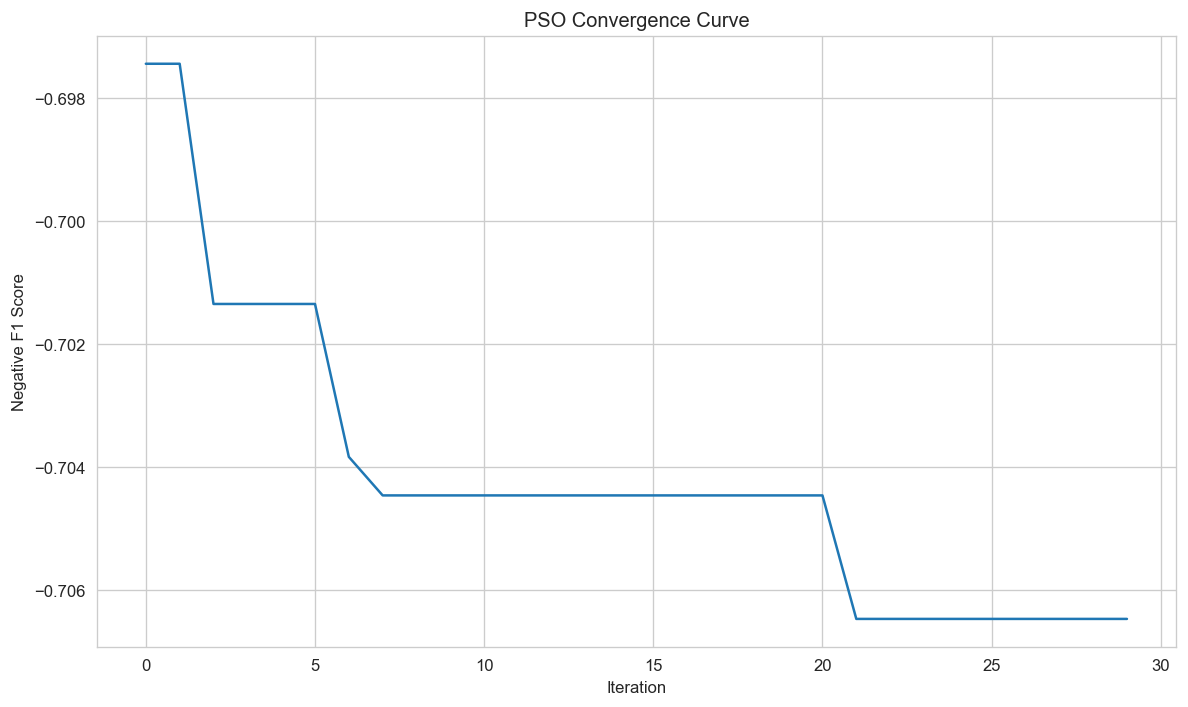

In [14]:
# %% Particle Swarm Optimization (PySwarms)
# Use only red wines for speed
data_sub = data[data['type'] == 1]
X_sub = data_sub.drop('quality', axis=1)
y_sub = data_sub['quality']

X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
    X_sub, y_sub, stratify=y_sub, test_size=0.10, random_state=21
)

# Scale the subset
ct.fit(X_train_sub)
X_train_scaled_sub = ct.transform(X_train_sub)
X_test_scaled_sub = ct.transform(X_test_sub)

# Define objective function for PSO
knn_weights = ['uniform', 'distance']
knn_algorithms = ['auto', 'ball_tree', 'kd_tree', 'brute']

def objective_function(params):
    n_particles = params.shape[0]
    fitness = np.zeros(n_particles)
    for i in range(n_particles):
        n_neighbors = max(1, int(params[i, 0]))
        weights_idx = int(params[i, 1]) % len(knn_weights)
        algorithm_idx = int(params[i, 2]) % len(knn_algorithms)
        leaf_size = max(1, int(params[i, 3]))
        p = max(1, min(5, abs(params[i, 4])))
        knn_params = {
            'n_neighbors': n_neighbors,
            'weights': knn_weights[weights_idx],
            'algorithm': knn_algorithms[algorithm_idx],
            'leaf_size': leaf_size,
            'p': p
        }
        try:
            model = KNeighborsClassifier(**knn_params)
            scores = cross_val_score(model, X_train_scaled_sub, y_train_sub,
                                     cv=stratified_cv, scoring='f1_weighted', n_jobs=-1)
            fitness[i] = -np.mean(scores)
        except Exception:
            fitness[i] = 0.0
    return fitness

# Configure PSO
dimensions = 5
lower_bounds = np.array([1, 0, 0, 1, 1])
upper_bounds = np.array([1000, 1.999, 3.999, 1000, 5])
bounds = (lower_bounds, upper_bounds)

options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 3, 'p': 2}
optimizer = ps.single.LocalBestPSO(n_particles=20, dimensions=dimensions,
                                   options=options, bounds=bounds)

cost, pos = optimizer.optimize(objective_function, iters=30, verbose=True)

# Decode best solution
best_params_pso = {
    'n_neighbors': max(1, int(pos[0])),
    'weights': knn_weights[int(pos[1]) % len(knn_weights)],
    'algorithm': knn_algorithms[int(pos[2]) % len(knn_algorithms)],
    'leaf_size': max(1, int(pos[3])),
    'p': max(1, min(5, abs(pos[4])))
}

print("\nBest hyperparameters (PSO):")
for k, v in best_params_pso.items():
    print(f"{k:>15}: {v}")
print("Best CV score (negative F1): {:.4f}".format(-cost))

final_model_pso = KNeighborsClassifier(**best_params_pso)
final_model_pso.fit(X_train_scaled_sub, y_train_sub)
test_accuracy = final_model_pso.score(X_test_scaled_sub, y_test_sub)
print("Test accuracy: {:.4f}".format(test_accuracy))

# Plot PSO convergence
plt.figure(figsize=(10, 6))
plt.plot(optimizer.cost_history)
plt.title('PSO Convergence Curve')
plt.xlabel('Iteration')
plt.ylabel('Negative F1 Score')
plt.grid(True)
plt.tight_layout()
#plt.savefig('plots/pso_convergence.png', dpi=300)
plt.show()

## 9. Summary and Next Steps

**Accomplished:**
- Implemented and compared six hyperparameter optimisation techniques on the Wine Quality dataset using a K‑Nearest Neighbors classifier.
- **Grid Search** – exhaustive but computationally expensive; found a good set of parameters.
- **Random Search** – faster than grid search and explored a wider space; found similar or better parameters.
- **Bayesian Optimization (scikit-optimize)** – efficiently guided the search with a probabilistic model, achieving competitive results.
- **Bayesian Optimization (Optuna)** – offered flexibility and built‑in pruning; achieved the best cross‑validated F1 score.
- **Genetic Algorithm (DEAP)** – evolved a population over generations; found a good solution, but more stochastic and computationally intensive.
- **Particle Swarm Optimization (PySwarms)** – used swarm intelligence to find parameters; achieved reasonable performance on a subset.

**Key Results (Comparison of Methods):**

| Method                     | Best CV F1 (weighted) | Test F1 (weighted) | Comments |
|----------------------------|-----------------------|--------------------|----------|
| Baseline (default KNN)     | –                     | 0.5947             | No tuning |
| Grid Search                | 0.6872                | 0.6749             | Exhaustive, 96 combos |
| Random Search              | 0.6936                | 0.6994             | Wider search, 70 iterations |
| Bayes (scikit-optimize)    | 0.6972                | 0.6965             | 40 iterations, efficient |
| Bayes (Optuna)             | 0.6972                | 0.6965             | 100 trials, flexible |
| Genetic Algorithm (DEAP)   | 0.6958 (max)          | 0.7061             | 50 generations, stochastic |
| PSO (PySwarms)             | 0.7065 (on subset)    | 0.7250 (accuracy)  | 30 iterations, on red wines only |

*Note:* All methods improved over the baseline. Bayesian approaches (Optuna and scikit‑optimise) achieved high cross‑validated scores with fewer evaluations than grid search. Random search also performed well, especially given its simplicity. Metaheuristics (GA and PSO) are more complex but can be useful for large or non‑continuous search spaces.

**Key Insights:**
- **Grid Search** is reliable for small spaces but does not scale.
- **Random Search** is a good default choice for larger spaces, often finding good parameters with fewer trials.
- **Bayesian Optimization** is more sample‑efficient and can outperform random search, especially when evaluations are expensive.
- **Optuna** stands out for its flexibility, parallelism, and pruning features, making it a modern choice for hyperparameter tuning.
- **Metaheuristics** (GA, PSO) are powerful but require careful tuning of their own parameters; they may be overkill for this problem but illustrate the breadth of optimisation techniques available.
- The choice of optimisation method depends on the problem size, available computational budget, and required performance.

**Suggested Next Steps:**
1. **Apply to More Complex Models:** Test these techniques on more expensive models (e.g., XGBoost, neural networks) to see the benefits of sample‑efficient methods like Bayesian optimisation.
2. **Use Optuna's Pruning:** Implement early stopping of unpromising trials to further speed up optimisation.
3. **Parallelise Trials:** Use distributed computing to run multiple evaluations concurrently.
4. **Explore Multi‑Objective Optimisation:** Optimise both accuracy and model complexity (e.g., training time) simultaneously.
5. **Integrate with Pipelines:** Combine hyperparameter tuning with feature selection and preprocessing steps using `Pipeline` and `search` objects.
6. **Visualise Optimisation Progress:** Create plots showing the evolution of the best score over trials/generations for each method.
7. **Automate the Best Method:** Wrap the chosen optimiser into a reusable function for future projects.
8. **Hyperparameter Importance Analysis:** Use Optuna's `importance` module to identify which hyperparameters have the greatest impact on performance.

**Reflection:**
This notebook provides a comprehensive tour of hyperparameter optimisation techniques, from classic grid and random search to advanced Bayesian and metaheuristic methods. The comparison highlights that while simple methods are often sufficient, more sophisticated approaches can yield better results with fewer evaluations. The code is modular and can be easily adapted to other models and datasets. The key takeaway is to choose the right tool based on the problem size and constraints – there is no one‑size‑fits‑all solution, but Bayesian optimisation, especially with Optuna, offers a modern and powerful default for many scenarios.